In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import ast
import re


In [2]:
def modify(results_df):
    
    results_combined = results_df.copy()[['prediction','ground_truth', 'ground_truth_text', 'ID', 'generated_text']]
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    
    return results_combined

In [3]:
# eval_type = "Neuropath"
eval_type = "AMYLPET"
# eval_type = "NP_ONE"
# eval_type = "NP_MIXED"
# eval_type = "COGSTAT"
# eval_type = "ETPR"
qwen25_3B_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_{eval_type}.csv"
qwen25_7B_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_7B_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_prev_run_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_prev_run_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_2epochs_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_2epochs_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_sce_tanh_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs_{eval_type}.csv"
# qwen25_3B_drgrpo_gp8_nacc_inc_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp8_nacc_inc_{eval_type}.csv"
# qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01_{eval_type}.csv"{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle_{eval_type}.csv"
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001_{eval_type}.csv"
qwen25_7B_drgrpo_gp8_nacc_inc_oversample_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_7B_drgrpo_gp8_nacc_inc_oversample_{eval_type}.csv"

qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh_{eval_type}.csv"


# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_sce_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_{eval_type}.csv"
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards_path = f"../llm_answer_extractor/extracted_results_sub/{eval_type}/qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards_{eval_type}.csv"


In [4]:
# benchmark_type = "nacc_sub"
benchmark_type = "medqa_nacc_sub"

In [5]:
qwen25_3B = pd.read_csv(qwen25_3B_path)
qwen25_7B = pd.read_csv(qwen25_7B_path)
# qwen25_3B_drgrpo_gp16_nacc_prev_run = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_prev_run_path)
# qwen25_3B_drgrpo_gp16_nacc = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_path)
# qwen25_3B_drgrpo_gp16_nacc_2epochs = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_2epochs_path)
qwen25_3B_drgrpo_gp16_nacc_inc = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_path)
qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh_path)
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_sce_tanh_path)
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs_path)
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_path)
# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs_path)
# qwen25_3B_drgrpo_gp8_nacc_inc = pd.read_csv(qwen25_3B_drgrpo_gp8_nacc_inc_path)
# qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh = pd.read_csv(qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh_path)
qwen25_3B_drgrpo_gp16_nacc_inc_oversample = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_oversample_path)
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_path)
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle_path)
# qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01 = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01_path)

qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001 = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001_path)

qwen25_7B_drgrpo_gp8_nacc_inc_oversample = pd.read_csv(qwen25_7B_drgrpo_gp8_nacc_inc_oversample_path)
qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh = pd.read_csv(qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh_path)

# qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05 = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05_path)
# qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs = pd.read_csv(qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_sce_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02 = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_path)
# qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards = pd.read_csv(qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards_path)

In [6]:
models = {
    "qwen25_3B": qwen25_3B,
    # "qwen25_3B_drgrpo_gp16_nacc_prev_run": qwen25_3B_drgrpo_gp16_nacc_prev_run,
    # "qwen25_3B_drgrpo_gp16_nacc": qwen25_3B_drgrpo_gp16_nacc,
    # "qwen25_3B_drgrpo_gp16_nacc_2epochs": qwen25_3B_drgrpo_gp16_nacc_2epochs,
    # "qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale": qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale,
    # "qwen25_3B_drgrpo_gp16_nacc_sce_tanh": qwen25_3B_drgrpo_gp16_nacc_sce_tanh,
    # "qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs": qwen25_3B_drgrpo_gp16_nacc_sce_tanh_2epochs,
    "qwen25_3B_drgrpo_gp16_nacc_inc": qwen25_3B_drgrpo_gp16_nacc_inc,
    "qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh": qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh,
    # "qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs": qwen25_3B_drgrpo_gp16_nacc_sce_tanh_no_scale_2epochs,
    # "qwen25_3B_drgrpo_gp8_nacc_inc": qwen25_3B_drgrpo_gp8_nacc_inc,
    # "qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh": qwen25_3B_drgrpo_gp8_nacc_inc_sce_tanh,
    "qwen25_3B_drgrpo_gp16_nacc_inc_oversample": qwen25_3B_drgrpo_gp16_nacc_inc_oversample,
    "qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh": qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh,
    "qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle": qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle,
    # "qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01": qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_01,
    "qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001": qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001,
    # "qwen25_7B": qwen25_7B,
    # "qwen25_7B_drgrpo_gp8_nacc_inc_oversample": qwen25_7B_drgrpo_gp8_nacc_inc_oversample,
    # "qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh": qwen25_7B_drgrpo_gp8_nacc_inc_oversample_sce_tanh,
    
    # "qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05": qwen25_3B_drgrpo_gp16_nacc_sce_tanh_05,
    # "qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs": qwen25_3B_drgrpo_gp16_nacc_filtered_sce_tanh_2epochs,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc": qwen25_3B_drgrpo_gp16_medqa_nacc,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_sce": qwen25_3B_drgrpo_gp16_medqa_nacc_sce,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards": qwen25_3B_drgrpo_gp16_medqa_nacc_sce_scale_rewards,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_filtered": qwen25_3B_drgrpo_gp16_medqa_nacc_filtered,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02": qwen25_3B_drgrpo_gp16_medqa_nacc_sce_02,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce": qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards": qwen25_3B_drgrpo_gp16_medqa_nacc_filtered_sce_scale_rewards,
    # "qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh": qwen25_3B_drgrpo_gp16_medqa_nacc_sce_tanh,
}

modified_models = {name: modify(df) for name, df in models.items()}

In [7]:
gt_dict = {
    "Neuropath": [
        "Alzheimer's disease pathology (AD) only",
        "Lewy body pathology (LBD) only",
        "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD) only",
        "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)",
        "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "No listed option is correct",
    ],
    "ETPR": [
        "Alzheimer's disease (AD)",
        "Lewy body disease (LBD)",
        "Frontotemporal lobar degeneration and its variants, including primary progressive aphasia, corticobasal degeneration and progressive supranuclear palsy, and with or without amyotrophic lateral sclerosis (FTLD)",
        "Vascular brain injury or vascular dementia including stroke (VD)",
        "Systemic and environmental factors including infectious diseases (HIV included), metabolic, substance abuse / alcohol, medications, systemic disease and delirium (SEF)",
        "Psychiatric conditions including schizophrenia, depression, bipolar disorder, anxiety and posttraumatic stress disorder (PSY)",
        "Other (Multiple system atrophy, Essential tremor, Down syndrome, Huntington's disease, Prion disease, Traumatic brain injury, Normal-pressure hydrocephalus, Epilepsy, CNS neoplasm, etc)",
        "Not applicable (no cognitive impairment)",
    ],
    "MCI": [
        "Amnestic MCI",
        "Non-amnestic MCI",
        "Not applicable (no diagnosis of MCI)",
    ],
    "COGSTAT": [
        "Normal Cognition (NC)",
        "Mild Cognitive Impairment (MCI)",
        "Dementia (DE)"
    ],
    "AMYLPET": [
        "Yes",
        "No"
    ],
    "NP_ONE": [
        "Alzheimer's disease pathology (AD)",
        "Lewy body pathology (LBD)",
        "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "No listed option is correct",
    ],
    "NP_MIXED": [
        "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)",
        "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)",
        "No listed option is correct",
    ],
}

In [ ]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    # print(n)
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n


In [9]:
def combine_results_by_ground_truth(results_dict, k):
    """
    Like combine_results, but computes pass@1 and cons@k separately for each ground_truth.
    Returns a DataFrame with columns: ['ground_truth', 'metric', 'model', 'score']
    """
    all_records = []

    # Iterate over each model and its corresponding DataFrame in the results dictionary
    for model_name, df in results_dict.items():
        # For each unique ground truth label in the DataFrame
        for gt in df['ground_truth_text'].unique():
            # Filter the DataFrame for the current ground truth
            df_gt = df[df['ground_truth_text'] == gt].reset_index(drop=True)
            # Assign a group number to each unique problem (by 'ID')
            # df_gt.index = df_gt.groupby('ID', sort=False).ngroup()
            # # Reset index and add a 'problem' column for grouping
            # df_gt = df_gt.reset_index(names=['problem']).reset_index(drop=True)
            # print(df_gt)  # For debugging: show the processed DataFrame
            
            df_gt['problem'] = df_gt.groupby('ID').ngroup()

            # Number of unique problems
            n = len(df_gt['ID'].unique())
            # Number of attempts per problem (assumes equal number for all)
            p = len(df_gt) // n
            # print(gt, n, p)  # For debugging: show current ground truth, n, and p

            # Compute pass@k score for this ground truth and model
            pass_score = pass_at_k(df_gt, p, k)
            # pass_score = get_passat1(df_gt)  # Alternative: use pass@1 function

            # Compute consistency@k score for this ground truth and model
            cons_score = get_consatk(df_gt, n)

            # Append pass@1 result to the records list
            all_records.append({
                'ground_truth': gt,
                'metric': 'pass@1',
                'model': model_name,
                'score': pass_score,
                'size': len(df_gt),
            })
            # Optionally, append cons@k result (currently commented out)
            # all_records.append({
            #     'ground_truth': gt,
            #     'metric': 'cons@k',
            #     'model': model_name,
            #     'score': cons_score,
            #     'size': len(df_gt),
            # })

    # Convert the list of records to a DataFrame and return
    return pd.DataFrame(all_records)


In [10]:
def plot_model_comparison_by_gt(df_long, k=1, out_path="np_by_gt.pdf"):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Exclude clinician for barplot, but keep for reference line
    df_no_clinician = df_long[df_long["model"] != "clinician"]

    # Order models by mean score (ascending)
    model_order = (
        df_long.groupby('model')['score']
        .mean()
        .sort_values()
        .index.tolist()
    )

    # Color palette: key models (not drgrpo) in red, others in blue
    models = df_no_clinician["model"].unique()
    key_models = [m for m in models if "drgrpo" not in m.lower()]
    other_models = [m for m in models if m not in key_models]
    palette = dict(zip(key_models, sns.color_palette("Reds", len(key_models))))
    palette.update(zip(other_models, sns.color_palette("Blues", len(other_models))))

    # Set ground truth order
    sorted_gt = gt_dict[eval_type]
    df_no_clinician["ground_truth"] = pd.Categorical(df_no_clinician["ground_truth"], categories=sorted_gt, ordered=True)

    # Plot with model order
    g = sns.catplot(
        data=df_no_clinician,
        kind="bar",
        x="metric", y="score", hue="model",
        col="ground_truth", col_wrap=1,
        # palette=palette,
        palette="Spectral",
        height=4.5, aspect=1.3,
        # hue_order=model_order  # <--- enforce model order by mean score
    )

    # Add clinician reference line if present
    clinician_df = df_long[df_long["model"] == "clinician"]
    if not clinician_df.empty:
        for ax, col_name in zip(g.axes.flatten(), g.col_names):
            val = clinician_df[
                (clinician_df["ground_truth"] == col_name) &
                (clinician_df["metric"] == "pass@1")
            ]["score"]
            if not val.empty:
                ax.axhline(val.values[0], linestyle='--', color='red', alpha=0.7, label="Clinician")

    # Add bar labels
    for ax in g.axes.flatten():
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

    g.set_titles("Ground Truth: {col_name}")
    g.set_axis_labels("Metric", "Score")
    g.set(ylim=(0, 1.05))

    # Handle legend: show only once outside the main plots
    handles, labels = g.axes[-1].get_legend_handles_labels()
    if g._legend:
        g._legend.remove()
    # Remove legends from all axes
    for ax in g.axes.flatten():
        ax.legend_.remove() if hasattr(ax, "legend_") and ax.legend_ else None

    # Place a single legend outside the main plot area, top left
    g.fig.legend(
        handles, labels, title='Model', frameon=False, loc='upper left',
        bbox_to_anchor=(0.01, 0.99), fontsize='small', title_fontsize='small'
    )

    plt.tight_layout(rect=[0.4, 0, 1, 1])  # leave space for legend on the left
    # plt.savefig(f"../llm_answer_extractor/outputs_sub/subgroups/nacc_sub/{eval_type.lower()}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f"../llm_answer_extractor/outputs_sub/subgroups/{benchmark_type}/{eval_type.lower()}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    plt.show()


In [11]:
df_long = combine_results_by_ground_truth(modified_models, k=1)

In [12]:
df_long

,ground_truth,metric,model,score,size
0,Yes,pass@1,qwen25_3B,0.597701,435
1,No,pass@1,qwen25_3B,0.706977,215
2,Yes,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc,0.802299,435
3,No,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc,0.600000,215
4,Yes,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh,0.832184,435
5,No,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh,0.595349,215
6,Yes,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_oversample,0.836782,435
7,No,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_oversample,0.576744,215
8,Yes,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_...,0.786207,435
9,No,pass@1,qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_...,0.600000,215


In [78]:
(df_long.groupby('model').apply(lambda x: (x['score'] * x['size']).sum() / x['size'].sum())
 .sort_values())

/tmp/ipykernel_2382352/3900727498.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  (df_long.groupby('model').apply(lambda x: (x['score'] * x['size']).sum() / x['size'].sum())


model
qwen25_3B                                                 0.475435
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle         0.498080
qwen25_3B_drgrpo_gp16_nacc_inc_oversample                 0.508638
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh        0.516282
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001    0.521258
qwen25_3B_drgrpo_gp16_nacc_inc                            0.602346
qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh                   0.612407
dtype: float64

In [79]:
df_long.groupby('model')['score'].mean().sort_values()

model
qwen25_3B                                                 0.265904
qwen25_3B_drgrpo_gp16_nacc_inc                            0.394734
qwen25_3B_drgrpo_gp16_nacc_inc_sce_tanh                   0.395257
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh_001    0.438880
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_shuffle         0.454786
qwen25_3B_drgrpo_gp16_nacc_inc_oversample_sce_tanh        0.459882
qwen25_3B_drgrpo_gp16_nacc_inc_oversample                 0.468765
Name: score, dtype: float64

In [80]:
benchmark_type

'medqa_nacc_sub'

In [81]:
df_long.groupby('model')['score'].mean().sort_values().to_csv(f"../llm_answer_extractor/outputs_sub/subgroups/{benchmark_type}/{eval_type.lower()}.csv")

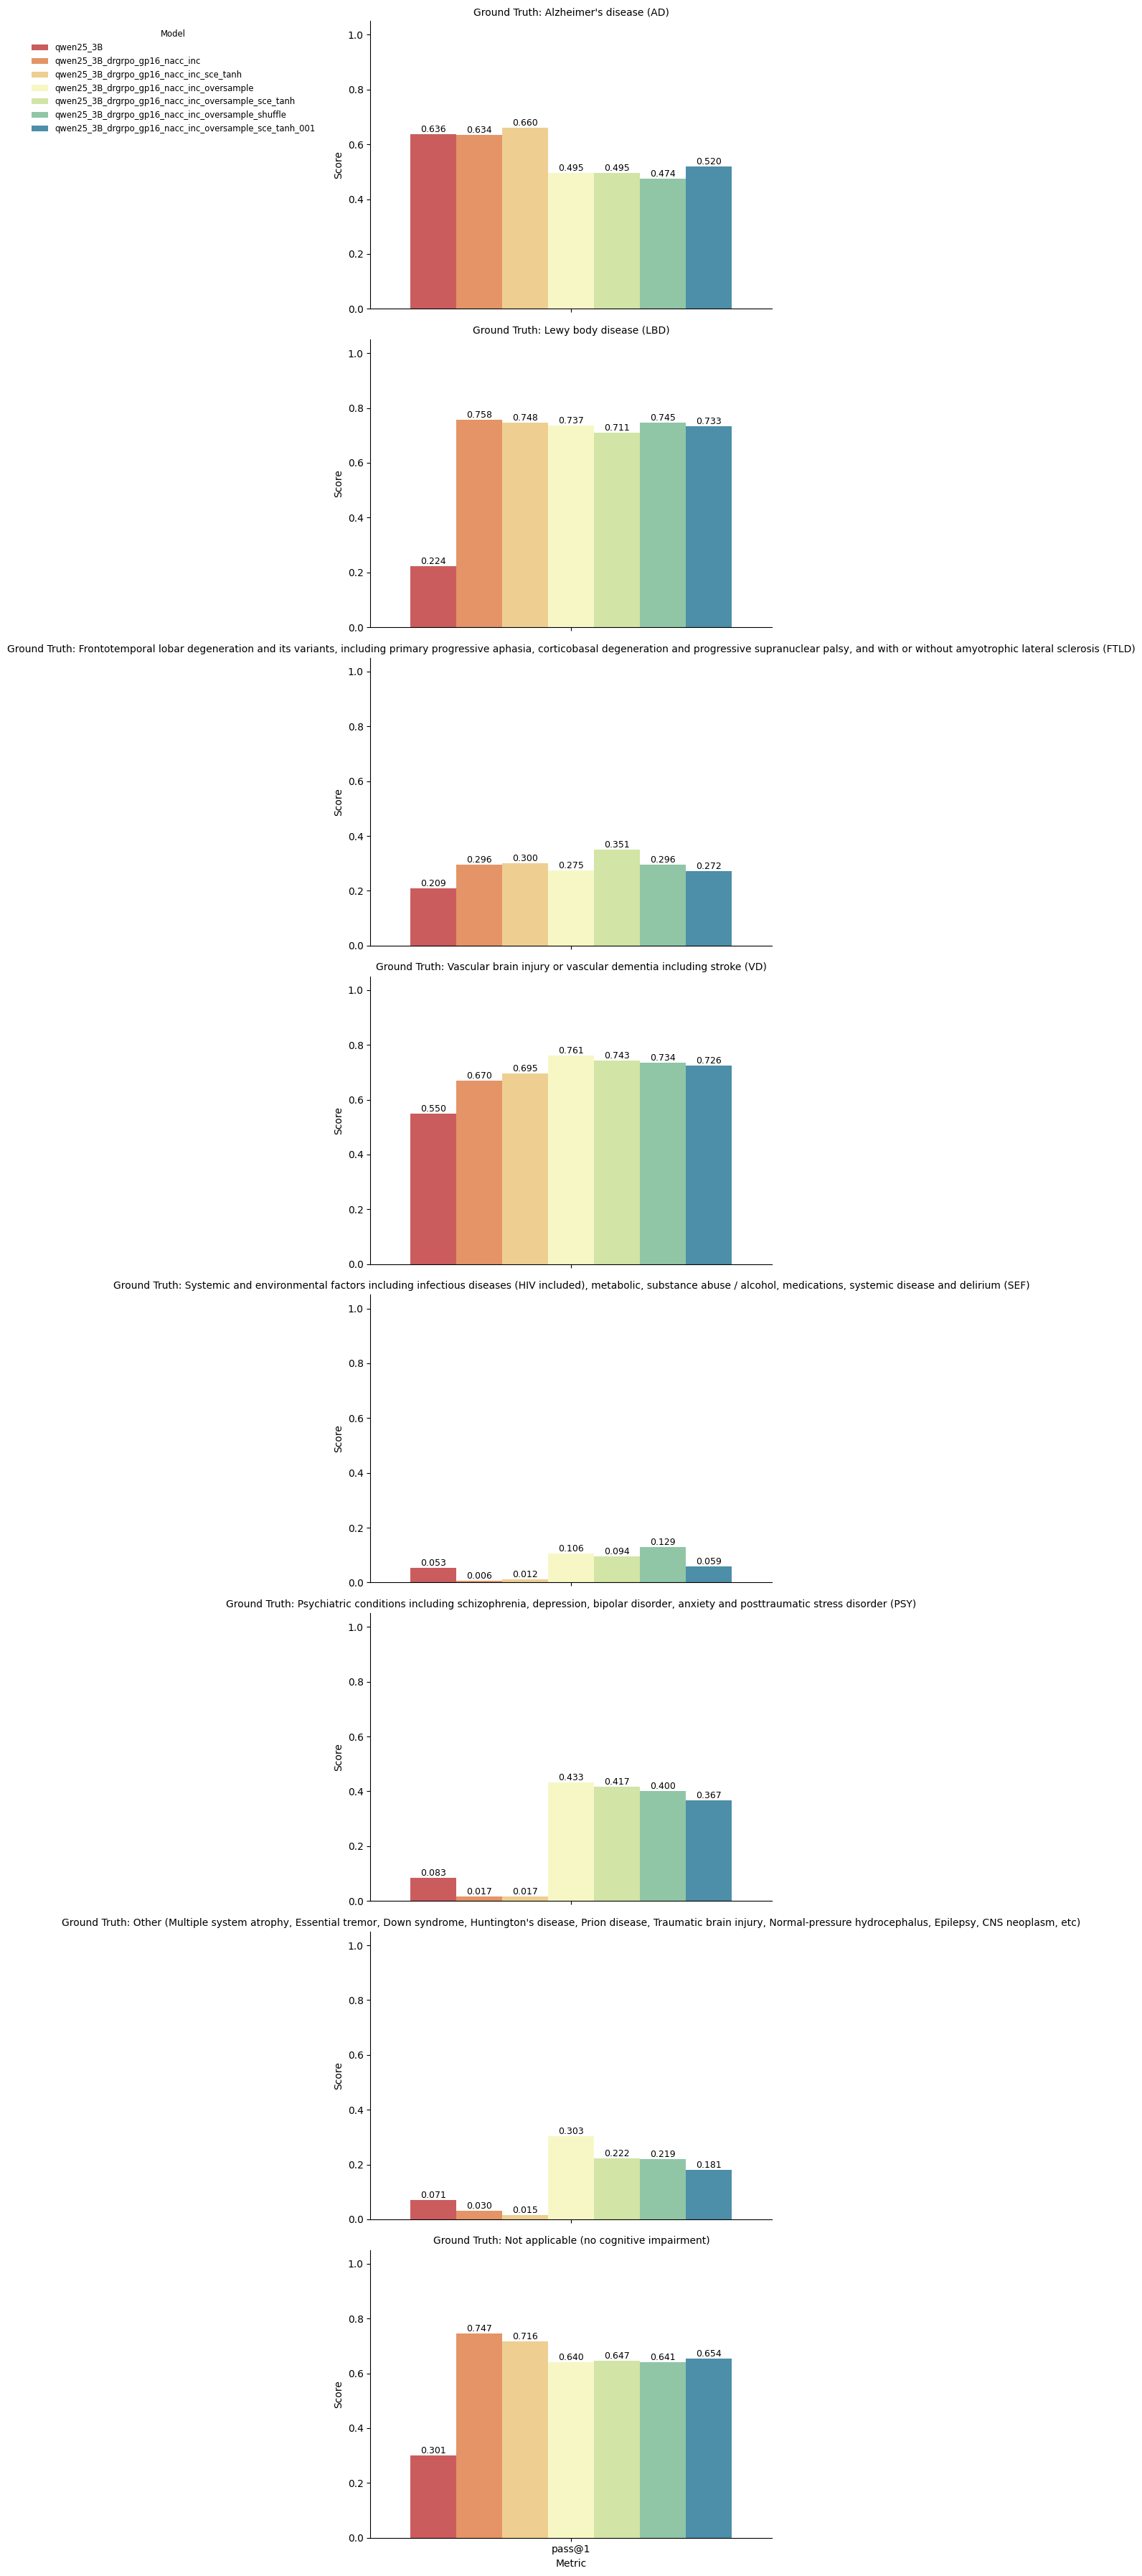

In [82]:
plot_model_comparison_by_gt(df_long, k=1)